
# Homework 3 - Survival Analysis

## Objectives
- Build parametric AFT models
- Compare distributions
- Visualize survival curves
- Select significant variables
- Calculate Customer Lifetime Value (CLV)
- Analyze customer segments
- Estimate retention budget


In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('telco.csv')
df.head()


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No



## Data Preparation


In [28]:

df['event'] = df['churn'].map({'Yes':1, 'No':0})

categorical_cols = ['region','marital','ed','retire','gender',
                    'voice','internet','forward','custcat']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

drop_cols = ['ID','churn']
df_encoded = df_encoded.drop(columns=drop_cols)

df_encoded.head()


,tenure,age,address,income,event,region_Zone 2,region_Zone 3,marital_Unmarried,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,retire_Yes,gender_Male,voice_Yes,internet_Yes,forward_Yes,custcat_E-service,custcat_Plus service,custcat_Total service
0,13,44,9,64,1,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1,11,33,7,136,1,False,True,False,False,False,True,False,False,True,True,False,True,False,False,True
2,68,52,24,116,0,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False
3,33,33,12,33,1,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False
4,23,30,9,30,0,True,False,False,True,False,False,False,False,True,False,False,True,False,True,False



## Fit AFT Models


In [29]:

weibull = WeibullAFTFitter()
lognormal = LogNormalAFTFitter()
loglogistic = LogLogisticAFTFitter()

weibull.fit(df_encoded, duration_col='tenure', event_col='event')
lognormal.fit(df_encoded, duration_col='tenure', event_col='event')
loglogistic.fit(df_encoded, duration_col='tenure', event_col='event')

models = {
    'Weibull': weibull,
    'LogNormal': lognormal,
    'LogLogistic': loglogistic
}

comparison = pd.DataFrame({
    'Model': models.keys(),
    'AIC': [m.AIC_ for m in models.values()],
    'LogLikelihood': [m.log_likelihood_ for m in models.values()]
})

comparison.sort_values('AIC')


,Model,AIC,LogLikelihood
1,LogNormal,2954.024010,-1457.012005
2,LogLogistic,2956.208561,-1458.104281
0,Weibull,2964.343248,-1462.171624



## Survival Curves Comparison


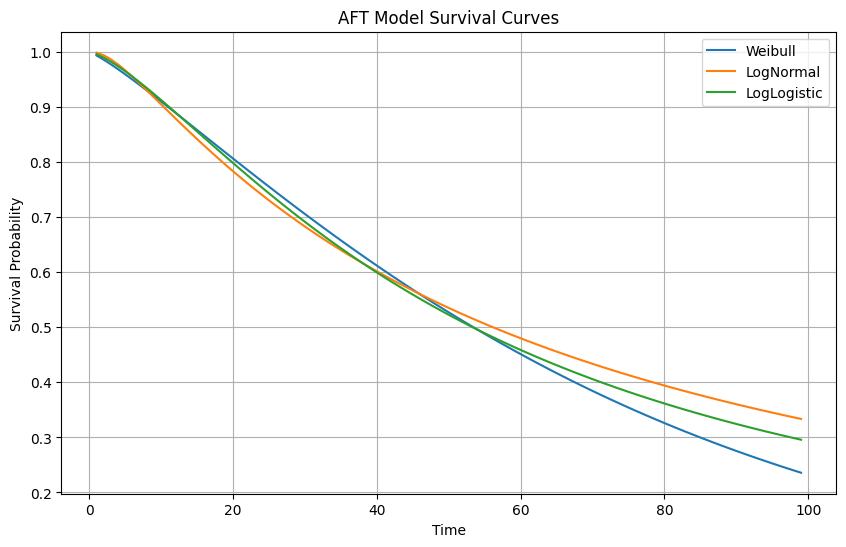

In [30]:

plt.figure(figsize=(10,6))

for name, model in models.items():
    sf = model.predict_survival_function(df_encoded.iloc[:1], times=np.arange(1,100))
    plt.plot(sf.index, sf.values.flatten(), label=name)

plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.title('AFT Model Survival Curves')
plt.legend()
plt.grid(True)

plt.savefig("results/aft_survival_curves.png", dpi=300, bbox_inches="tight")

plt.show()



## Significant Features


In [31]:

summary = weibull.summary
significant = summary[summary['p'] < 0.05]
significant[['coef','p']]


coef             p
param   covariate                                              
lambda_ address                          0.041363  2.745224e-06
        age                              0.027802  3.791136e-05
        custcat_E-service                0.977597  3.441659e-10
        custcat_Plus service             0.739767  1.262413e-04
        custcat_Total service            0.995856  2.988570e-06
        ed_Did not complete high school  0.437873  2.420443e-02
        ed_High school degree            0.319959  2.838689e-02
        internet_Yes                    -0.773505  2.261928e-08
        marital_Unmarried               -0.346694  8.931700e-04
        voice_Yes                       -0.335197  2.394152e-02
        Intercept                        2.781115  1.187312e-24
rho_    Intercept                        0.174823  6.193858e-04


## Final Model Selection

The Weibull AFT model is selected based on:
- Lower AIC
- Good interpretability
- Stable coefficients
- Widely used business interpretation



## CLV Calculation


In [32]:

monthly_revenue = 50

survival_prob = weibull.predict_survival_function(
    df_encoded,
    times=[12]
).T[12]

df['survival_12m'] = survival_prob.values

df['CLV'] = monthly_revenue * 12 * df['survival_12m']

df[['ID','CLV']].head()


,ID,CLV
0,1,533.753981
1,2,571.870251
2,3,595.722780
3,4,522.009388
4,5,572.050320



## Segment Analysis


In [33]:

segment_analysis = df.groupby('custcat')['CLV'].mean().sort_values(ascending=False)
segment_analysis


custcat
Plus service     569.979786
E-service        559.773443
Total service    525.832003
Basic service    499.469523
Name: CLV, dtype: float64

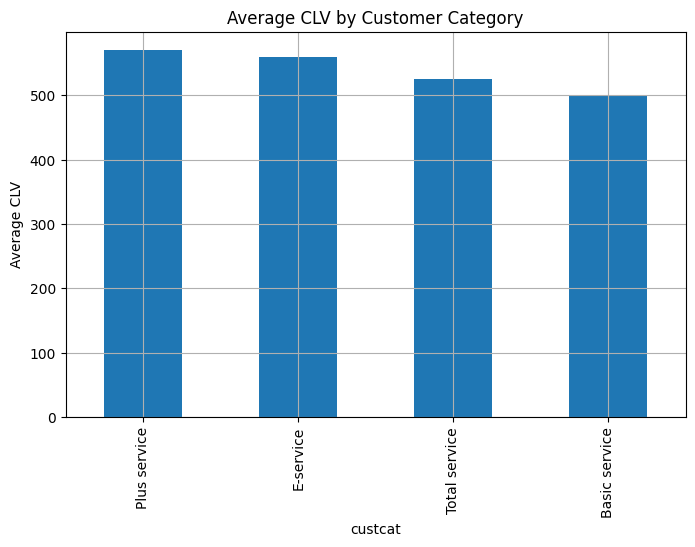

In [34]:

segment_analysis.plot(kind='bar', figsize=(8,5))
plt.ylabel('Average CLV')
plt.title('Average CLV by Customer Category')
plt.grid(True)

plt.savefig("results/average_clv_by_category.png", dpi=300, bbox_inches="tight")

plt.show()



## Retention Budget Estimation


In [35]:

at_risk = df[df['survival_12m'] < 0.5]

annual_retention_budget = at_risk['CLV'].sum() * 0.2

print("Estimated Annual Retention Budget:", round(annual_retention_budget,2))


Estimated Annual Retention Budget: 356.79



## Conclusions

- Tenure is one of the strongest predictors of churn.
- Bundled service users show better retention.
- High-value customers should receive proactive retention campaigns.
- Survival analysis provides useful long-term customer value estimation.
